In [1]:
library(tidyverse)
library(ggthemes)
library(ggtext)

# ── Name mappings ──
subj_name_map <- c(
  "e2.tts" = "E2-TTS", "f5.tts" = "F5-TTS", "fish.speech" = "Fish Speech",
  "gpt.sovits" = "GPT-SoVITS", "hierspeech" = "HierSpeech", "indextts" = "IndexTTS2",
  "maskgct" = "MaskGCT", "metavoice" = "Metavoice", "openvoice" = "OpenVoice",
  "qwen3.tts" = "Qwen3-TTS", "styletts2" = "StyleTTS2", "tortoise" = "TorToiSe",
  "vevo" = "Vevo", "vibevoice" = "VibeVoice", "voicecraft" = "VoiceCraft",
  "whisperspeech" = "WhisperSpeech", "xtts" = "XTTS", "recording" = "Recording"
)
obj_name_map <- c(
  "e2-tts" = "E2-TTS", "f5-tts" = "F5-TTS", "fish-speech" = "Fish Speech",
  "gpt-sovits" = "GPT-SoVITS", "hierspeech" = "HierSpeech", "indextts" = "IndexTTS2",
  "maskgct" = "MaskGCT", "metavoice" = "Metavoice", "openvoice" = "OpenVoice",
  "qwen3-tts" = "Qwen3-TTS", "styletts2" = "StyleTTS2", "tortoise" = "TorToiSe",
  "vevo" = "Vevo", "vibevoice" = "VibeVoice", "voicecraft" = "VoiceCraft",
  "whisperspeech" = "WhisperSpeech", "xtts" = "XTTS", "recording" = "Recording"
)
ttsds_name_map <- c(
  "e2-tts/default/eng" = "E2-TTS", "f5-tts/v1/eng" = "F5-TTS",
  "fish-speech/s1-mini/eng" = "Fish Speech", "gpt-sovits/v4/eng" = "GPT-SoVITS",
  "hierspeech/v1.1/eng" = "HierSpeech", "indextts/default/eng" = "IndexTTS2",
  "maskgct/default/eng" = "MaskGCT", "metavoice/default/eng" = "Metavoice",
  "openvoice/default/eng" = "OpenVoice", "qwen3-tts/1.7b-base/eng" = "Qwen3-TTS",
  "styletts2/default/eng" = "StyleTTS2", "tortoise/default/eng" = "TorToiSe",
  "vevo/vevo1.5/eng" = "Vevo", "vibevoice/default/eng" = "VibeVoice",
  "voicecraft/giga830m_tts_enhanced/eng" = "VoiceCraft",
  "whisperspeech/small/eng" = "WhisperSpeech", "xtts/v2/eng" = "XTTS",
  "recording/default/eng" = "Recording"
)

cat("Setup complete.\n")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors
Setup complete.


Rows: 193 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): severity_computed, disorder_type, speaker_name, readable_name
dbl (1): recording_wer

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


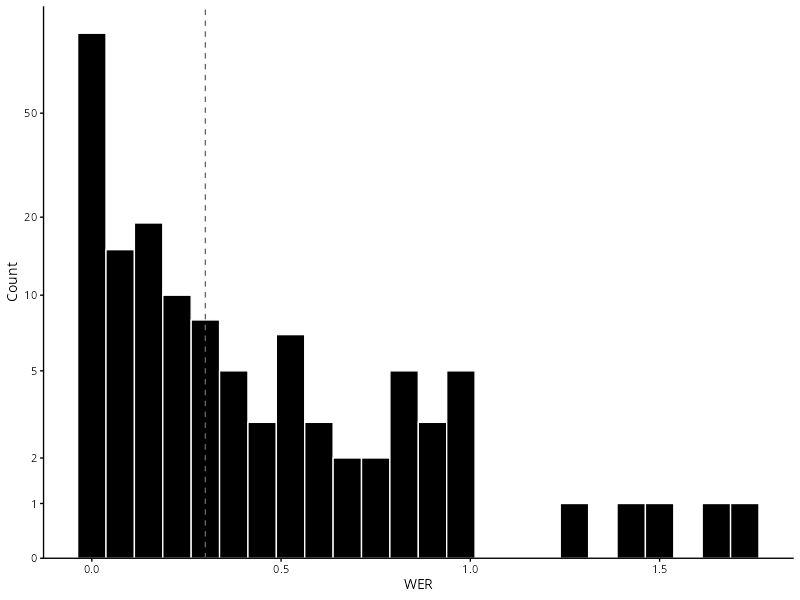

In [2]:
# ── WER histogram across speakers ──
speakers <- read_csv("results/speaker_list.csv")

ggplot(speakers, aes(x = recording_wer)) +
  geom_histogram(binwidth = 0.15 / 2, fill = "black", colour = "white") +
  geom_vline(xintercept = 0.3, linetype = "dashed", colour = "grey40") +
  scale_y_continuous(trans = scales::pseudo_log_trans(base = 10),
                     breaks = c(0, 1, 2, 5, 10, 20, 50),
                     expand = expansion(mult = c(0, 0.05))) +
  labs(x = "WER", y = "Count") +
  theme_classic(base_size = 14)

ggsave("plots/wer_histogram.pdf", width = 6, height = 3)

In [3]:
# ── Load subjective BWS worth estimates ──
intel_ranking <- read_csv("results/all/subjective/intel_ranking.csv") %>%
  filter(item %in% names(subj_name_map)) %>%
  mutate(system = subj_name_map[item]) %>%
  select(system, p_vs_recording)

sim_ranking <- read_csv("results/all/subjective/sim_ranking.csv") %>%
  filter(item %in% names(subj_name_map)) %>%
  mutate(system = subj_name_map[item]) %>%
  select(system, p_vs_recording)

intel_worth <- read_csv("results/all/subjective/intel_worth.csv") %>%
  filter(item %in% names(subj_name_map)) %>%
  mutate(system = subj_name_map[item],
         ci95 = 1.96 * quasiSE) %>%
  left_join(intel_ranking, by = "system") %>%
  mutate(sig = !is.na(p_vs_recording) & p_vs_recording < 0.05) %>%
  arrange(estimate)

sim_worth <- read_csv("results/all/subjective/sim_worth.csv") %>%
  filter(item %in% names(subj_name_map)) %>%
  mutate(system = subj_name_map[item],
         ci95 = 1.96 * quasiSE) %>%
  left_join(sim_ranking, by = "system") %>%
  mutate(sig = !is.na(p_vs_recording) & p_vs_recording < 0.05) %>%
  arrange(estimate)

cat(sprintf("Intel systems: %d, Reconstruction systems: %d\n", nrow(intel_worth), nrow(sim_worth)))

Rows: 18 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): item
dbl (11): rank, estimate, SE, quasiSE, quasiVar, estimate_vs_mean, se_vs_mea...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 18 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): item
dbl (11): rank, estimate, SE, quasiSE, quasiVar, estimate_vs_mean, se_vs_mea...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 18 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): item
dbl (4): estimate, SE, quasiSE, quasiVar

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column t

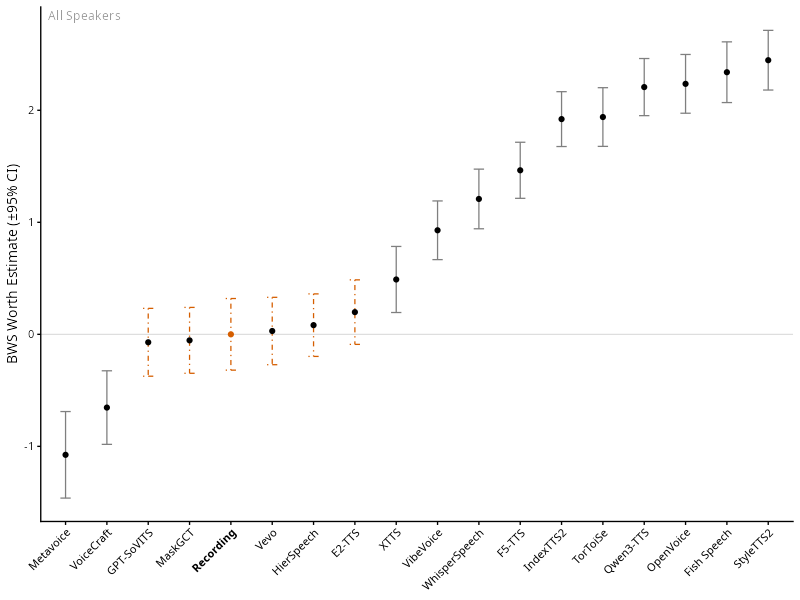

In [4]:
# ── Caterpillar / coefficient plot: Intelligibility (vertical) ──
intel_worth <- intel_worth %>% mutate(system = factor(system, levels = system))

ggplot(intel_worth, aes(y = estimate, x = system)) +
  geom_hline(yintercept = 0, colour = "grey85", linewidth = 0.5) +
  geom_errorbar(aes(ymin = estimate - ci95, ymax = estimate + ci95,
                    linetype = sig, colour = sig),
                width = 0.25, linewidth = 0.6) +
geom_point(aes(fill = system == "Recording"), size = 2.5, shape = 21, colour = "#00000000") +
  scale_fill_manual(values = c("TRUE" = "#D55E00", "FALSE" = "black"), guide = "none") +
  scale_colour_manual(values = c("TRUE" = "grey50", "FALSE" = "#D55E00"), guide = "none") +
  scale_linetype_manual(values = c("TRUE" = "solid", "FALSE" = "dotdash"), guide = "none") +
  scale_x_discrete(labels = function(x) ifelse(x == "Recording", "**Recording**", x)) +
  labs(y = "BWS Worth Estimate (±95% CI)", x = NULL) +
  annotate("text", x = -Inf, y = Inf, label = "All Speakers",
           hjust = -0.1, vjust = 1.5, colour = "grey60", size = 4.5) +
  theme_classic(base_size = 14) +
  theme(axis.text.x = element_markdown(angle = 45, hjust = 1))

ggsave("plots/subjective_intelligibility.pdf", width = 8, height = 3.5)

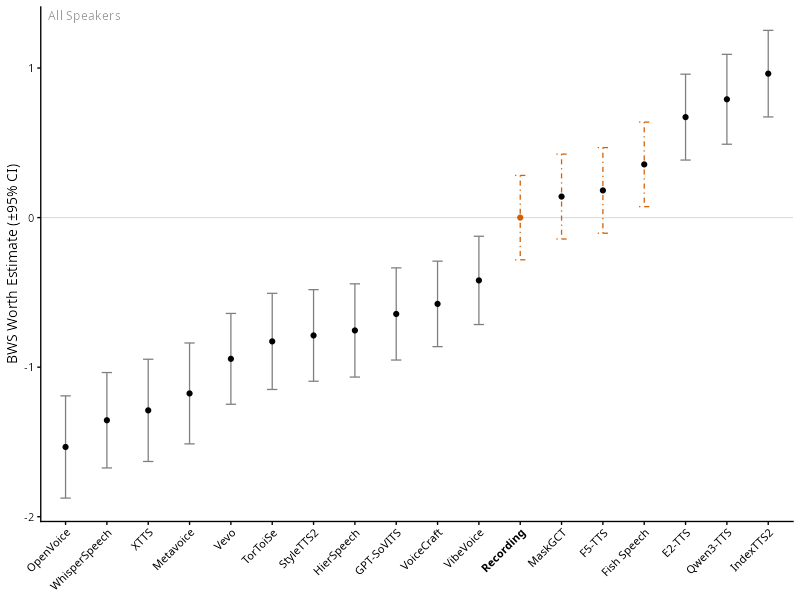

In [5]:
# ── Caterpillar / coefficient plot: Reconstruction (vertical) ──
sim_worth <- sim_worth %>% mutate(system = factor(system, levels = system))

ggplot(sim_worth, aes(y = estimate, x = system)) +
  geom_hline(yintercept = 0, colour = "grey85", linewidth = 0.5) +
  geom_errorbar(aes(ymin = estimate - ci95, ymax = estimate + ci95,
                    linetype = sig, colour = sig),
                width = 0.25, linewidth = 0.6) +
  geom_point(aes(fill = system == "Recording"), size = 2.5, shape = 21, colour = "#00000000") +
  scale_fill_manual(values = c("TRUE" = "#D55E00", "FALSE" = "black"), guide = "none") +
  scale_colour_manual(values = c("TRUE" = "grey50", "FALSE" = "#D55E00"), guide = "none") +
  scale_linetype_manual(values = c("TRUE" = "solid", "FALSE" = "dotdash"), guide = "none") +
  scale_x_discrete(labels = function(x) ifelse(x == "Recording", "**Recording**", x)) +
  labs(y = "BWS Worth Estimate (±95% CI)", x = NULL) +
  annotate("text", x = -Inf, y = Inf, label = "All Speakers",
           hjust = -0.1, vjust = 1.5, colour = "grey60", size = 4.5) +
  theme_classic(base_size = 14) +
  theme(axis.text.x = element_markdown(angle = 45, hjust = 1))

ggsave("plots/subjective_reconstruction.pdf", width = 8, height = 3.5)

In [ ]:
# ── Build combined metrics table for Spearman correlations ──

# Objective metrics
obj_spk_sim <- read_csv("results/all/objective/aggregated_spk_sim.csv") %>%
  filter(model %in% names(obj_name_map)) %>%
  mutate(system = obj_name_map[model]) %>%
  select(system, spk_sim = spk_sim_mean)

obj_utmos <- read_csv("results/all/objective/aggregated_utmos.csv") %>%
  filter(model %in% names(obj_name_map)) %>%
  mutate(system = obj_name_map[model]) %>%
  select(system, utmos = utmos_mean)

obj_wer <- read_csv("results/all/objective/aggregated_wer.csv") %>%
  filter(model %in% names(obj_name_map)) %>%
  mutate(system = obj_name_map[model]) %>%
  select(system, wer = wer_mean)

obj_per <- read_csv("results/all/objective/aggregated_per.csv") %>%
  filter(model %in% names(obj_name_map)) %>%
  mutate(system = obj_name_map[model]) %>%
  select(system, per = per_mean)

# TTSDS with original reference (SAP readable)
ttsds_ref <- read_csv("results/sap__sap_readable_01/aggregated_results_sap__sap_readable_01.csv") %>%
  filter(dataset %in% names(ttsds_name_map), benchmark_category == "OVERALL") %>%
  mutate(system = ttsds_name_map[dataset]) %>%
  select(system, ttsds_ref = score_mean)

# TTSDS with LibriTTS (clean reference)
ttsds_lib <- read_csv("results/sap__libritts/aggregated_results_sap__libritts.csv") %>%
  filter(dataset %in% names(ttsds_name_map), benchmark_category == "OVERALL") %>%
  mutate(system = ttsds_name_map[dataset]) %>%
  select(system, ttsds_clean = score_mean)

# Subjective rankings (worth estimates)
subj <- intel_worth %>%
  select(system, subj_intel = estimate) %>%
  inner_join(sim_worth %>% select(system, subj_recon = estimate), by = "system")

# Join everything
metrics <- subj %>%
  inner_join(obj_spk_sim, by = "system") %>%
  inner_join(obj_utmos, by = "system") %>%
  inner_join(obj_wer, by = "system") %>%
  inner_join(obj_per, by = "system") %>%
  inner_join(ttsds_ref, by = "system") %>%
  inner_join(ttsds_lib, by = "system") %>%
  mutate(ttsds_mean = (ttsds_ref + ttsds_clean) / 2,
         ttsds_hmean = 2 * ttsds_ref * ttsds_clean / (ttsds_ref + ttsds_clean),
         ttsds_weighted = -0.5 * ttsds_ref + 0.5 * ttsds_clean,
         ttsds_weighted2 = ((100 - ttsds_ref) + ttsds_clean) / 2)

cat(sprintf("Systems in joined table: %d\n", nrow(metrics)))
metrics

Rows: 18 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): model
dbl (3): spk_sim_mean, spk_sim_std, n_utterances

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 18 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): model
dbl (3): utmos_mean, utmos_std, n_utterances

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 18 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): model
dbl (3): wer_mean, wer_std, n_utterances

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1

# A tibble: 18 × 10
   system subj_intel subj_recon spk_sim utmos    wer   per ttsds_ref ttsds_clean
   <chr>       <dbl>      <dbl>   <dbl> <dbl>  <dbl> <dbl>     <dbl>       <dbl>
 1 Metav…    -1.08       -1.18    0.418  2.09 0.433  0.768      80.9        77.6
 2 Voice…    -0.654      -0.577   0.374  2.42 0.359  0.726      88.3        78.6
 3 GPT-S…    -0.0710     -0.644   0.504  2.57 0.270  0.702      87.3        82.7
 4 MaskG…    -0.0537      0.141   0.627  2.58 0.175  0.617      90.8        79.3
 5 Recor…     0           0       0.645  2.36 0.206  0.986      93.6        77.4
 6 Vevo       0.0296     -0.944   0.563  2.67 0.348  0.662      87.1        81.2
 7 HierS…     0.0819     -0.755   0.496  3.62 0.137  0.476      88.9        78.6
 8 E2-TTS     0.198       0.672   0.713  2.61 0.308  0.660      90.6        81.9
 9 XTTS       0.490      -1.29    0.404  2.63 0.173  0.581      86.0        80.9
10 VibeV…     0.929      -0.420   0.486  2.75 0.186  0.575      88.7        83.0
11 Whisp

In [ ]:
# ── Spearman correlation table: objective/TTSDS → subjective rankings ──

predictors <- c(
  "spk_sim"      = "Speaker Similarity",
  "wer"          = "WER",
  "per"          = "PER",
  "utmos"        = "UTMOS",
  "ttsds_ref"    = "TTSDS Reference",
  "ttsds_clean"  = "TTSDS Clean",
  "ttsds_mean"   = "TTSDS Mean",
  "ttsds_hmean"     = "TTSDS HMean",
  "ttsds_weighted"  = "TTSDS Weighted",
  "ttsds_weighted2" = "TTSDS Weighted2"
)
outcomes <- c("subj_intel" = "Intelligibility", "subj_recon" = "Reconstruction")

rows <- list()
for (pred_col in names(predictors)) {
  for (out_col in names(outcomes)) {
    test <- cor.test(metrics[[pred_col]], metrics[[out_col]], method = "spearman", exact = FALSE)
    stars <- ifelse(test$p.value < 0.001, "***",
             ifelse(test$p.value < 0.01, "**",
             ifelse(test$p.value < 0.05, "*", "")))
    rows <- c(rows, list(tibble(
      Predictor = predictors[pred_col],
      Outcome   = outcomes[out_col],
      rho       = round(test$estimate, 3),
      p         = round(test$p.value, 4),
      sig       = stars
    )))
  }
}

cor_table <- bind_rows(rows)

# Pivot to wide format: one row per predictor, columns for each outcome
cor_wide <- cor_table %>%
  mutate(label = sprintf("%.3f %s (p=%.4f)", rho, sig, p)) %>%
  select(Predictor, Outcome, label) %>%
  pivot_wider(names_from = Outcome, values_from = label)

cor_wide

# A tibble: 7 × 3
  Predictor          Intelligibility       Reconstruction      
  <chr>              <chr>                 <chr>               
1 Speaker Similarity -0.245  (p=0.3280)    0.746 *** (p=0.0004)
2 WER                -0.802 *** (p=0.0001) -0.018  (p=0.9449)  
3 PER                -0.759 *** (p=0.0003) 0.150  (p=0.5534)   
4 UTMOS              0.864 *** (p=0.0000)  -0.090  (p=0.7231)  
5 TTSDS Reference    -0.573 * (p=0.0130)   0.470 * (p=0.0493)  
6 TTSDS Clean        0.853 *** (p=0.0000)  0.292  (p=0.2396)   
7 TTSDS Mean         0.034  (p=0.8933)     0.814 *** (p=0.0000)

In [ ]:
# ── Full system rankings by each predictor (All Speakers) ──
ranking_cols <- c(
  "subj_intel"  = "Intelligibility (Subj.)",
  "subj_recon"  = "Reconstruction (Subj.)",
  "spk_sim"     = "Speaker Similarity",
  "wer"         = "WER",
  "per"         = "PER",
  "utmos"       = "UTMOS",
  "ttsds_ref"   = "TTSDS Reference",
  "ttsds_clean" = "TTSDS Clean",
  "ttsds_mean"  = "TTSDS Mean",
  "ttsds_hmean"     = "TTSDS HMean",
  "ttsds_weighted"  = "TTSDS Weighted",
  "ttsds_weighted2" = "TTSDS Weighted2"
)

# Build a rank table: for each metric, rank systems (higher = better)
rank_df <- metrics %>% select(system)
for (col in names(ranking_cols)) {
  rank_df[[ranking_cols[col]]] <- rank(-metrics[[col]], ties.method = "min")
}

# For WER and PER, lower is better → rank ascending
rank_df[["WER"]] <- rank(metrics[["wer"]], ties.method = "min")
rank_df[["PER"]] <- rank(metrics[["per"]], ties.method = "min")

# Sort by subjective intelligibility rank
rank_df <- rank_df %>% arrange(`Intelligibility (Subj.)`)

cat("=== All Speakers: System Rankings ===\n")
print(rank_df, n = Inf)

=== All Speakers: System Rankings ===
# A tibble: 18 × 10
   system     Intelligibility (Sub…¹ Reconstruction (Subj…² `Speaker Similarity`
   <chr>                       <int>                  <int>                <int>
 1 StyleTTS2                       1                     12                   17
 2 Fish Spee…                      2                      4                   10
 3 OpenVoice                       3                     18                   18
 4 Qwen3-TTS                       4                      2                    6
 5 TorToiSe                        5                     13                   16
 6 IndexTTS2                       6                      1                    2
 7 F5-TTS                          7                      5                    5
 8 WhisperSp…                      8                     17                   12
 9 VibeVoice                       9                      8                   11
10 XTTS                           10               

In [9]:
# ── Low Intelligibility: Load subjective BWS worth estimates ──
intel_ranking_li <- read_csv("results/very_high_wer/subjective/intel_ranking.csv") %>%
  filter(item %in% names(subj_name_map)) %>%
  mutate(system = subj_name_map[item]) %>%
  select(system, p_vs_recording)

sim_ranking_li <- read_csv("results/very_high_wer/subjective/sim_ranking.csv") %>%
  filter(item %in% names(subj_name_map)) %>%
  mutate(system = subj_name_map[item]) %>%
  select(system, p_vs_recording)

intel_worth_li <- read_csv("results/very_high_wer/subjective/intel_worth.csv") %>%
  filter(item %in% names(subj_name_map)) %>%
  mutate(system = subj_name_map[item],
         ci95 = 1.96 * quasiSE) %>%
  left_join(intel_ranking_li, by = "system") %>%
  mutate(sig = !is.na(p_vs_recording) & p_vs_recording < 0.05) %>%
  arrange(estimate)

sim_worth_li <- read_csv("results/very_high_wer/subjective/sim_worth.csv") %>%
  filter(item %in% names(subj_name_map)) %>%
  mutate(system = subj_name_map[item],
         ci95 = 1.96 * quasiSE) %>%
  left_join(sim_ranking_li, by = "system") %>%
  mutate(sig = !is.na(p_vs_recording) & p_vs_recording < 0.05) %>%
  arrange(estimate)

cat(sprintf("Low Intel — Intel systems: %d, Reconstruction systems: %d\n",
            nrow(intel_worth_li), nrow(sim_worth_li)))

Rows: 18 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): item
dbl (11): rank, estimate, SE, quasiSE, quasiVar, estimate_vs_mean, se_vs_mea...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 18 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): item
dbl (11): rank, estimate, SE, quasiSE, quasiVar, estimate_vs_mean, se_vs_mea...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 18 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): item
dbl (4): estimate, SE, quasiSE, quasiVar

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column t

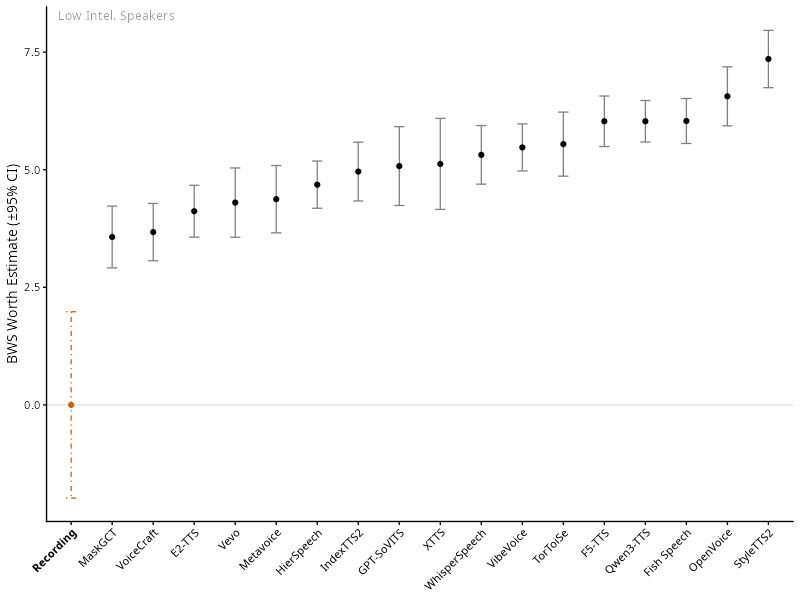

In [10]:
# ── Low Intelligibility: Caterpillar plot – Intelligibility (vertical) ──
intel_worth_li <- intel_worth_li %>% mutate(system = factor(system, levels = system))

ggplot(intel_worth_li, aes(y = estimate, x = system)) +
  geom_hline(yintercept = 0, colour = "grey85", linewidth = 0.5) +
  geom_errorbar(aes(ymin = estimate - ci95, ymax = estimate + ci95,
                    linetype = sig, colour = sig),
                width = 0.25, linewidth = 0.6) +
  geom_point(aes(fill = system == "Recording"), size = 2.5, shape = 21, colour = "#00000000") +
  scale_fill_manual(values = c("TRUE" = "#D55E00", "FALSE" = "black"), guide = "none") +
  scale_colour_manual(values = c("TRUE" = "grey50", "FALSE" = "#D55E00"), guide = "none") +
  scale_linetype_manual(values = c("TRUE" = "solid", "FALSE" = "dotdash"), guide = "none") +
  scale_x_discrete(labels = function(x) ifelse(x == "Recording", "**Recording**", x)) +
  labs(y = "BWS Worth Estimate (±95% CI)", x = NULL) +
  annotate("text", x = -Inf, y = Inf, label = "Low Intel. Speakers",
           hjust = -0.1, vjust = 1.5, colour = "grey60", size = 4.5) +
  theme_classic(base_size = 14) +
  theme(axis.text.x = element_markdown(angle = 45, hjust = 1))

ggsave("plots/subjective_intelligibility_low_intel.pdf", width = 8, height = 3.5)

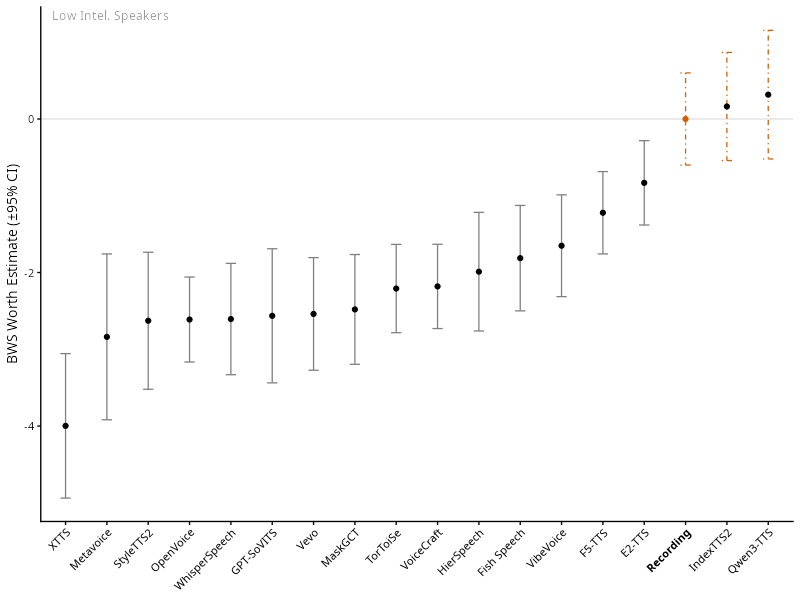

In [11]:
# ── Low Intelligibility: Caterpillar plot – Reconstruction (vertical) ──
sim_worth_li <- sim_worth_li %>% mutate(system = factor(system, levels = system))

ggplot(sim_worth_li, aes(y = estimate, x = system)) +
  geom_hline(yintercept = 0, colour = "grey85", linewidth = 0.5) +
  geom_errorbar(aes(ymin = estimate - ci95, ymax = estimate + ci95,
                    linetype = sig, colour = sig),
                width = 0.25, linewidth = 0.6) +
  geom_point(aes(fill = system == "Recording"), size = 2.5, shape = 21, colour = "#00000000") +
  scale_fill_manual(values = c("TRUE" = "#D55E00", "FALSE" = "black"), guide = "none") +
  scale_colour_manual(values = c("TRUE" = "grey50", "FALSE" = "#D55E00"), guide = "none") +
  scale_linetype_manual(values = c("TRUE" = "solid", "FALSE" = "dotdash"), guide = "none") +
  scale_x_discrete(labels = function(x) ifelse(x == "Recording", "**Recording**", x)) +
  labs(y = "BWS Worth Estimate (±95% CI)", x = NULL) +
  annotate("text", x = -Inf, y = Inf, label = "Low Intel. Speakers",
           hjust = -0.1, vjust = 1.5, colour = "grey60", size = 4.5) +
  theme_classic(base_size = 14) +
  theme(axis.text.x = element_markdown(angle = 45, hjust = 1))

ggsave("plots/subjective_reconstruction_low_intel.pdf", width = 8, height = 3.5)

In [ ]:
# ── Low Intelligibility: Build combined metrics table ──

obj_spk_sim_li <- read_csv("results/very_high_wer/objective/aggregated_spk_sim.csv") %>%
  filter(model %in% names(obj_name_map)) %>%
  mutate(system = obj_name_map[model]) %>%
  select(system, spk_sim = spk_sim_mean)

obj_utmos_li <- read_csv("results/very_high_wer/objective/aggregated_utmos.csv") %>%
  filter(model %in% names(obj_name_map)) %>%
  mutate(system = obj_name_map[model]) %>%
  select(system, utmos = utmos_mean)

obj_wer_li <- read_csv("results/very_high_wer/objective/aggregated_wer.csv") %>%
  filter(model %in% names(obj_name_map)) %>%
  mutate(system = obj_name_map[model]) %>%
  select(system, wer = wer_mean)

obj_per_li <- read_csv("results/very_high_wer/objective/aggregated_per.csv") %>%
  filter(model %in% names(obj_name_map)) %>%
  mutate(system = obj_name_map[model]) %>%
  select(system, per = per_mean)

ttsds_ref_li <- read_csv("results/sap_very_high_wer__sap_readable_01_very_high_wer/aggregated_results_sap_very_high_wer__sap_readable_01_very_high_wer.csv") %>%
  filter(dataset %in% names(ttsds_name_map), benchmark_category == "OVERALL") %>%
  mutate(system = ttsds_name_map[dataset]) %>%
  select(system, ttsds_ref = score_mean)

ttsds_lib_li <- read_csv("results/sap_very_high_wer__libritts/aggregated_results_sap_very_high_wer__libritts.csv") %>%
  filter(dataset %in% names(ttsds_name_map), benchmark_category == "OVERALL") %>%
  mutate(system = ttsds_name_map[dataset]) %>%
  select(system, ttsds_clean = score_mean)

subj_li <- intel_worth_li %>%
  select(system, subj_intel = estimate) %>%
  inner_join(sim_worth_li %>% select(system, subj_recon = estimate), by = "system")

metrics_li <- subj_li %>%
  inner_join(obj_spk_sim_li, by = "system") %>%
  inner_join(obj_utmos_li, by = "system") %>%
  inner_join(obj_wer_li, by = "system") %>%
  inner_join(obj_per_li, by = "system") %>%
  inner_join(ttsds_ref_li, by = "system") %>%
  inner_join(ttsds_lib_li, by = "system") %>%
  mutate(ttsds_mean = (ttsds_ref + ttsds_clean) / 2,
         ttsds_hmean = 2 * ttsds_ref * ttsds_clean / (ttsds_ref + ttsds_clean),
         ttsds_weighted = -0.5 * ttsds_ref + 0.5 * ttsds_clean,
         ttsds_weighted2 = ((100 - ttsds_ref) + ttsds_clean) / 2)

cat(sprintf("Low Intel — Systems in joined table: %d\n", nrow(metrics_li)))
metrics_li

Rows: 18 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): model
dbl (3): spk_sim_mean, spk_sim_std, n_utterances

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 18 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): model
dbl (3): utmos_mean, utmos_std, n_utterances

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 18 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): model
dbl (3): wer_mean, wer_std, n_utterances

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1

# A tibble: 18 × 10
   system  subj_intel subj_recon spk_sim utmos   wer   per ttsds_ref ttsds_clean
   <chr>        <dbl>      <dbl>   <dbl> <dbl> <dbl> <dbl>     <dbl>       <dbl>
 1 Record…       0         0       0.626  1.88 0.733 0.991      89.9        70.1
 2 MaskGCT       3.57     -2.48    0.583  2.26 0.362 0.798      86.9        73.2
 3 VoiceC…       3.67     -2.18    0.326  2.06 0.506 0.843      84.1        73.5
 4 E2-TTS        4.12     -0.832   0.650  2.24 0.456 0.800      86.5        76.5
 5 Vevo          4.30     -2.54    0.475  2.26 0.623 0.789      82.9        72.9
 6 Metavo…       4.37     -2.84    0.401  1.80 0.625 0.840      79.1        68.4
 7 HierSp…       4.68     -1.99    0.451  3.45 0.196 0.538      84.4        73.0
 8 IndexT…       4.96      0.163   0.645  2.53 0.147 0.659      84.4        78.1
 9 GPT-So…       5.08     -2.56    0.477  2.28 0.499 0.815      84.6        76.9
10 XTTS          5.12     -4.00    0.395  2.34 0.346 0.700      82.8        76.0
11 Whisp

In [ ]:
# ── Low Intelligibility: Spearman correlation table ──

predictors_li <- c(
  "spk_sim"      = "Speaker Similarity",
  "wer"          = "WER",
  "per"          = "PER",
  "utmos"        = "UTMOS",
  "ttsds_ref"    = "TTSDS Reference",
  "ttsds_clean"  = "TTSDS Clean",
  "ttsds_mean"   = "TTSDS Mean",
  "ttsds_hmean"     = "TTSDS HMean",
  "ttsds_weighted"  = "TTSDS Weighted",
  "ttsds_weighted2" = "TTSDS Weighted2"
)
outcomes_li <- c("subj_intel" = "Intelligibility", "subj_recon" = "Reconstruction")

rows_li <- list()
for (pred_col in names(predictors_li)) {
  for (out_col in names(outcomes_li)) {
    test <- cor.test(metrics_li[[pred_col]], metrics_li[[out_col]],
                     method = "spearman", exact = FALSE)
    stars <- ifelse(test$p.value < 0.001, "***",
             ifelse(test$p.value < 0.01, "**",
             ifelse(test$p.value < 0.05, "*", "")))
    rows_li <- c(rows_li, list(tibble(
      Predictor = predictors_li[pred_col],
      Outcome   = outcomes_li[out_col],
      rho       = round(test$estimate, 3),
      p         = round(test$p.value, 4),
      sig       = stars
    )))
  }
}

cor_table_li <- bind_rows(rows_li)

cor_wide_li <- cor_table_li %>%
  mutate(label = sprintf("%.3f %s (p=%.4f)", rho, sig, p)) %>%
  select(Predictor, Outcome, label) %>%
  pivot_wider(names_from = Outcome, values_from = label)

cat("=== Low Intelligibility Speakers ===\n")
cor_wide_li

=== Low Intelligibility Speakers ===


# A tibble: 7 × 3
  Predictor          Intelligibility       Reconstruction      
  <chr>              <chr>                 <chr>               
1 Speaker Similarity -0.503 * (p=0.0335)   0.610 ** (p=0.0072) 
2 WER                -0.593 ** (p=0.0094)  0.189  (p=0.4529)   
3 PER                -0.622 ** (p=0.0058)  0.271  (p=0.2760)   
4 UTMOS              0.831 *** (p=0.0000)  -0.051  (p=0.8421)  
5 TTSDS Reference    -0.752 *** (p=0.0003) 0.449  (p=0.0617)   
6 TTSDS Clean        0.851 *** (p=0.0000)  0.185  (p=0.4631)   
7 TTSDS Mean         -0.137  (p=0.5871)    0.734 *** (p=0.0005)

In [ ]:
# ── Full system rankings by each predictor (Low Intelligibility) ──
ranking_cols_li <- c(
  "subj_intel"  = "Intelligibility (Subj.)",
  "subj_recon"  = "Reconstruction (Subj.)",
  "spk_sim"     = "Speaker Similarity",
  "wer"         = "WER",
  "per"         = "PER",
  "utmos"       = "UTMOS",
  "ttsds_ref"   = "TTSDS Reference",
  "ttsds_clean" = "TTSDS Clean",
  "ttsds_mean"  = "TTSDS Mean",
  "ttsds_hmean"     = "TTSDS HMean",
  "ttsds_weighted"  = "TTSDS Weighted",
  "ttsds_weighted2" = "TTSDS Weighted2"
)

rank_df_li <- metrics_li %>% select(system)
for (col in names(ranking_cols_li)) {
  rank_df_li[[ranking_cols_li[col]]] <- rank(-metrics_li[[col]], ties.method = "min")
}

# For WER and PER, lower is better → rank ascending
rank_df_li[["WER"]] <- rank(metrics_li[["wer"]], ties.method = "min")
rank_df_li[["PER"]] <- rank(metrics_li[["per"]], ties.method = "min")

rank_df_li <- rank_df_li %>% arrange(`Intelligibility (Subj.)`)

cat("=== Low Intelligibility Speakers: System Rankings ===\n")
print(rank_df_li, n = Inf)

=== Low Intelligibility Speakers: System Rankings ===
# A tibble: 18 × 10
   system     Intelligibility (Sub…¹ Reconstruction (Subj…² `Speaker Similarity`
   <chr>                       <int>                  <int>                <int>
 1 StyleTTS2                       1                     16                   15
 2 OpenVoice                       2                     15                   18
 3 Fish Spee…                      3                      7                   11
 4 Qwen3-TTS                       4                      1                    9
 5 F5-TTS                          5                      5                    5
 6 TorToiSe                        6                     10                   17
 7 VibeVoice                       7                      6                    8
 8 WhisperSp…                      8                     14                   14
 9 XTTS                            9                     18                   13
10 GPT-SoVITS                     1

In [ ]:
# ── Correlation scatter plots: All Speakers ──
dir.create("plots/correlations", showWarnings = FALSE, recursive = TRUE)

pred_info <- list(
  list(col = "spk_sim",     label = "Speaker Similarity"),
  list(col = "wer",         label = "WER"),
  list(col = "per",         label = "PER"),
  list(col = "utmos",       label = "UTMOS"),
  list(col = "ttsds_ref",   label = "TTSDS Reference"),
  list(col = "ttsds_clean", label = "TTSDS Clean"),
  list(col = "ttsds_mean",  label = "TTSDS Mean"),
  list(col = "ttsds_hmean",    label = "TTSDS HMean"),
  list(col = "ttsds_weighted",  label = "TTSDS Weighted"),
  list(col = "ttsds_weighted2", label = "TTSDS Weighted2")
)
out_info <- list(
  list(col = "subj_intel", label = "Intelligibility (BWS Worth)"),
  list(col = "subj_recon", label = "Reconstruction (BWS Worth)")
)

for (pred in pred_info) {
  for (out in out_info) {
    test <- cor.test(metrics[[pred$col]], metrics[[out$col]],
                     method = "spearman", exact = FALSE)
    rho_label <- sprintf("rho == %.3f ~~~ italic(p) == %.4f", test$estimate, test$p.value)

    p <- ggplot(metrics, aes(x = .data[[pred$col]], y = .data[[out$col]])) +
      geom_smooth(method = "lm", se = TRUE, colour = "steelblue", fill = "steelblue",
                  alpha = 0.15, linewidth = 0.7) +
      geom_point(aes(fill = system == "Recording"), size = 3, shape = 21, colour = "white",
                 stroke = 0.4) +
      geom_text(aes(label = system), size = 2.5, vjust = -1, check_overlap = TRUE) +
      scale_fill_manual(values = c("TRUE" = "#D55E00", "FALSE" = "black"), guide = "none") +
      annotate("text", x = -Inf, y = Inf, label = rho_label, parse = TRUE,
               hjust = -0.05, vjust = 1.5, size = 3.8, colour = "grey30") +
      annotate("text", x = Inf, y = -Inf, label = "All Speakers",
               hjust = 1.1, vjust = -0.5, size = 4, colour = "grey60") +
      labs(x = pred$label, y = out$label) +
      theme_classic(base_size = 13)

    out_tag <- ifelse(out$col == "subj_intel", "intel", "recon")
    fname <- sprintf("plots/correlations/all_%s_vs_%s.pdf", pred$col, out_tag)
    ggsave(fname, p, width = 5.5, height = 4)
  }
}

cat("All Speakers correlation plots saved to plots/correlations/\n")

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
All Speakers correlation plots saved to plots/correlations/


In [16]:
# ── Correlation scatter plots: Low Intelligibility Speakers ──

for (pred in pred_info) {
  for (out in out_info) {
    test <- cor.test(metrics_li[[pred$col]], metrics_li[[out$col]],
                     method = "spearman", exact = FALSE)
    rho_label <- sprintf("rho == %.3f ~~~ italic(p) == %.4f", test$estimate, test$p.value)

    p <- ggplot(metrics_li, aes(x = .data[[pred$col]], y = .data[[out$col]])) +
      geom_smooth(method = "lm", se = TRUE, colour = "steelblue", fill = "steelblue",
                  alpha = 0.15, linewidth = 0.7) +
      geom_point(aes(fill = system == "Recording"), size = 3, shape = 21, colour = "white",
                 stroke = 0.4) +
      geom_text(aes(label = system), size = 2.5, vjust = -1, check_overlap = TRUE) +
      scale_fill_manual(values = c("TRUE" = "#D55E00", "FALSE" = "black"), guide = "none") +
      annotate("text", x = -Inf, y = Inf, label = rho_label, parse = TRUE,
               hjust = -0.05, vjust = 1.5, size = 3.8, colour = "grey30") +
      annotate("text", x = Inf, y = -Inf, label = "Low Intel. Speakers",
               hjust = 1.1, vjust = -0.5, size = 4, colour = "grey60") +
      labs(x = pred$label, y = out$label) +
      theme_classic(base_size = 13)

    out_tag <- ifelse(out$col == "subj_intel", "intel", "recon")
    fname <- sprintf("plots/correlations/low_intel_%s_vs_%s.pdf", pred$col, out_tag)
    ggsave(fname, p, width = 5.5, height = 4)
  }
}

cat("Low Intelligibility correlation plots saved to plots/correlations/\n")

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Low Intelligibility correlation plots saved to plots/correlations/
